In [19]:
import os
os.environ["JAX_PLATFORMS"] = "cpu"

from delayandsum import applyDAS

import matplotlib.pyplot as plt
import numpy as np

from skimage.metrics import peak_signal_noise_ratio
from skimage.metrics import structural_similarity
from scipy.stats import pearsonr

from jax import jit
from jax import numpy as jnp
from matplotlib import pyplot as plt

from jwave.geometry import TimeAxis
from jwave.geometry import Medium
from jwave.geometry import Domain
from jwave.geometry import Sensors, points_on_circle


from jwave import FourierSeries
from jwave.acoustics import simulate_wave_propagation
from jwave.geometry import *
from jwave.utils import show_field

from fbpinns.analysis import FBPINN_solution
from fbpinns.analysis import load_model

from trampa import WaveTrampa
import fbpinn_wave as fw

In [2]:
domain = Domain((240, 240), (0.5, 0.5))
medium = Medium(domain=domain, sound_speed=1.0, attenuation=0.0, pml_size=2.0)
dt = 0.5
time_axis = TimeAxis(dt=dt, t_end=50)
print(f"El dominio espacial en x va de {domain.spatial_axis[0].min()} m a {domain.spatial_axis[1].max()} m")
print(f"El dominio espacial en y va de {domain.spatial_axis[1].min()} m a {domain.spatial_axis[1].max()} m")

El dominio espacial en x va de -59.75 m a 59.75 m
El dominio espacial en y va de -59.75 m a 59.75 m


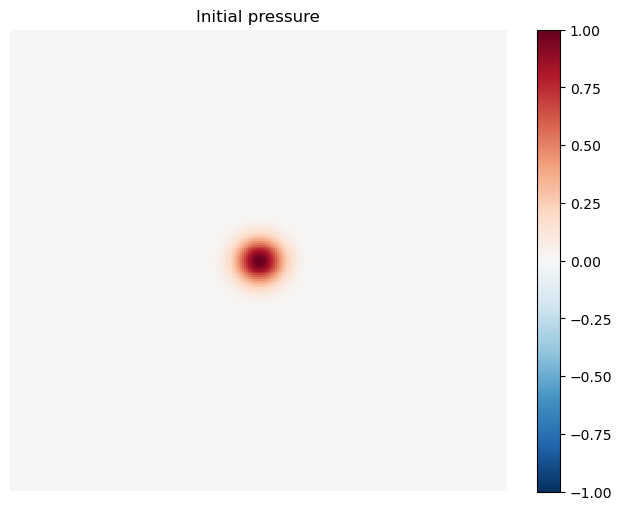

In [ ]:

N = domain.N

x, y = np.mgrid[0:N[0], 0:N[1]]
mui = jnp.array([-0, 0])/domain.dx[0] + np.array(N)/2
sigma = 4/domain.dx[0]
p0 = jnp.exp(-0.5*(x-mui[0])**2/sigma**2) * jnp.exp(-0.5*(y-mui[1])**2/sigma**2)
mui = jnp.array([-10, -15])/domain.dx[0] + np.array(N)/2

p0 = FourierSeries(p0, domain)

show_field(p0)
plt.title("Initial pressure")
plt.show()

In [4]:
num_sensors = 64
rx = 25
ri = rx/domain.dx[0]
xi, yi = points_on_circle(num_sensors, ri, (int(domain.N[0]/2), int(domain.N[0]/2)))
sensors_positions = (xi, yi)
sensors = Sensors(positions=sensors_positions)

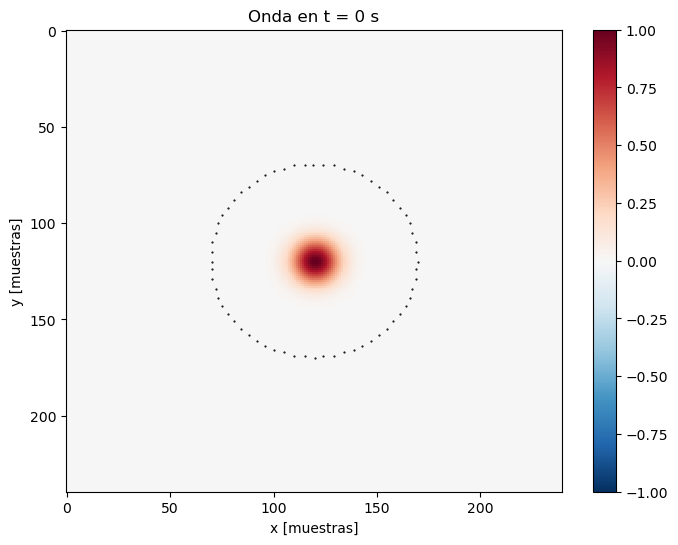

In [5]:
show_field(p0)
plt.scatter(xi, yi, c='black', s=0.3)
plt.title("Onda en t = 0 s")
plt.xlabel("x [muestras]")
plt.ylabel("y [muestras]")
plt.axis('on')
plt.axis()
plt.show()

In [6]:
@jit
def compiled_simulator(medium, p0):
    a = simulate_wave_propagation(medium, time_axis, p0=p0, sensors=sensors)
    return a

@jit
def compiled_simulator2(medium, p0):
    a = simulate_wave_propagation(medium, time_axis, p0=p0)
    return a

p = compiled_simulator2(medium, p0)
sensors_data = compiled_simulator(medium, p0)[..., 0]


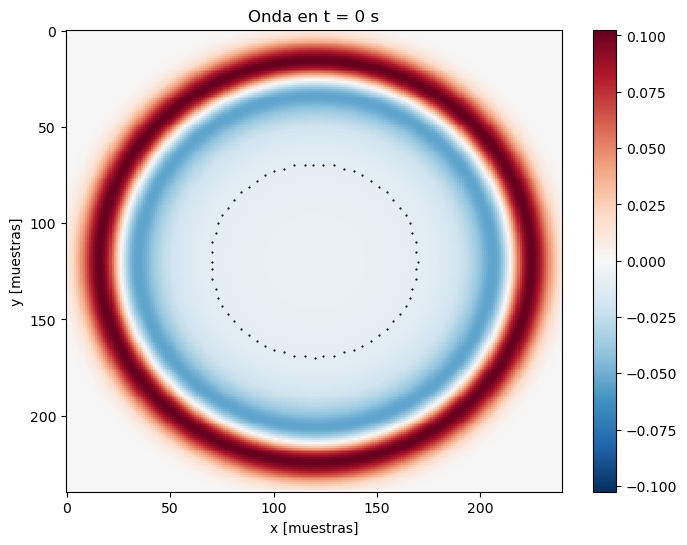

In [8]:
Nt = int(time_axis.Nt)
it = 200
i = it if it < Nt else Nt

show_field(p[i], "Onda en t = " + str(i*dt) + "s")
plt.scatter(xi, yi, c='black', s=0.3)
plt.title("Onda en t = 0 s")
plt.xlabel("x [muestras]")
plt.ylabel("y [muestras]")
plt.axis('on')
plt.axis()
plt.show()

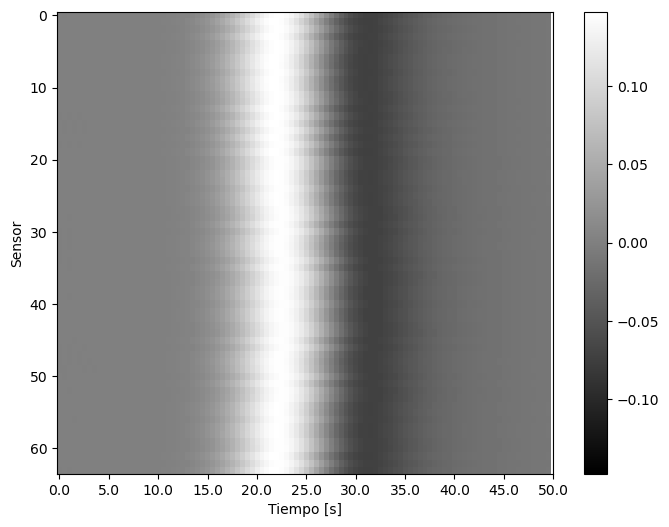

In [9]:
_field = FourierSeries(sensors_data.T, domain)
sinogram = _field.on_grid

plt.figure(figsize=(8,6))
maxval = jnp.amax(jnp.abs(sinogram))
plt.imshow(
    sinogram,
    cmap="gray",
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram.shape[1], num=num)
plt.xticks(t_ticks, np.round(t_ticks*dt, decimals=2))
#plt.title("Sinograma")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")
plt.show()

In [ ]:
WaveTrampa()

t = time_axis.to_array()
x = (np.array(xi)- domain.N[0]/2)*domain.dx[0]
y = (np.array(yi)- domain.N[1]/2)*domain.dx[0]

batch_shape = (len(x), t.shape[0])

xx, tt = np.meshgrid(x, t, indexing="xy")
yy, _ = np.meshgrid(y, t, indexing="xy")

const, model = load_model(run="test", i=100000, rootdir="pulse_2d0/results/")
_, all_params, _, active, _ = model

sinogram_fbpinn = FBPINN_solution(const, all_params, active, np.c_[xx.T.flatten(), yy.T.flatten(), tt.T.flatten()]).reshape(batch_shape)

[INFO] 2026-02-27 17:20:44 - Loading model from:
pulse_2d0/results/models/test/model_00100000.jax
[INFO] 2026-02-27 17:20:47 - x_batch
[INFO] 2026-02-27 17:20:47 - (6400, 3), float64, ndarray
[INFO] 2026-02-27 17:20:47 - x_take
[INFO] 2026-02-27 17:20:47 - (167310, 3), float64, ndarray


1.023e-04


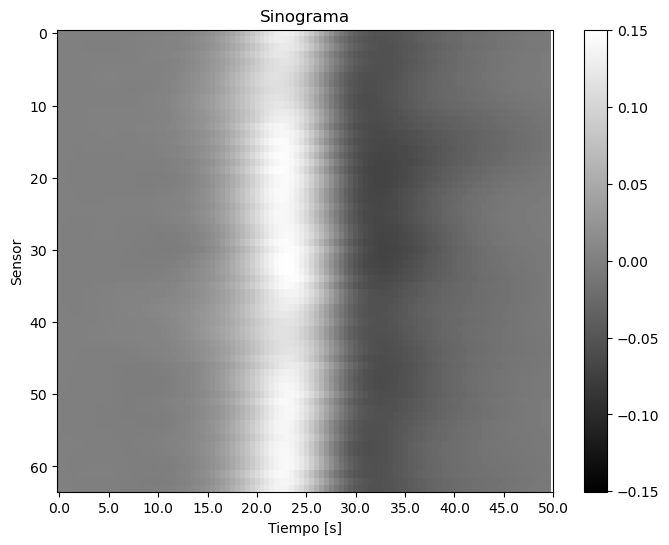

In [13]:
ec = (sinogram - sinogram_fbpinn)**2
ecm = np.format_float_scientific(np.mean(ec), precision=3)

plt.figure(figsize=(8,6))
maxval = jnp.amax(jnp.abs(sinogram_fbpinn))
plt.imshow(
    sinogram_fbpinn,
    cmap="gray",
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram.shape[1], num=num)
plt.xticks(t_ticks, np.round(t_ticks*dt, decimals=2))
plt.title("Sinograma")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")
print(ecm)
plt.show()

ECM = 1.023e-04


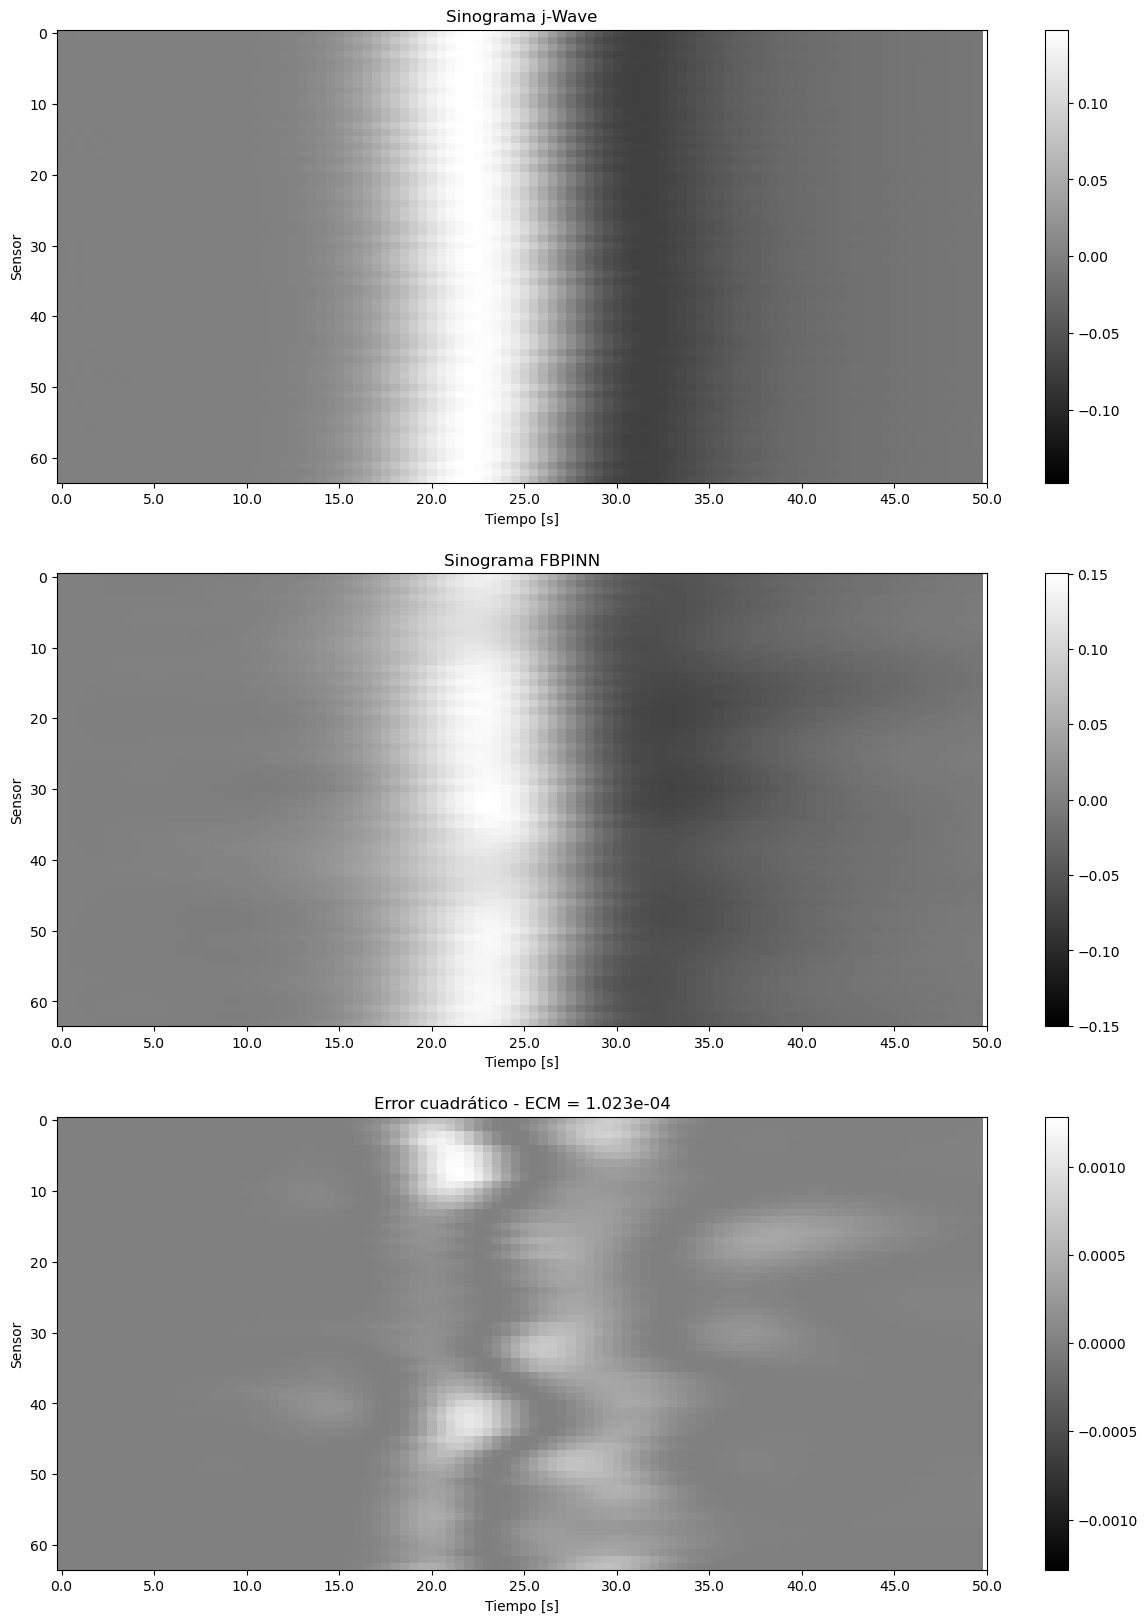

In [ ]:
ec = (sinogram - sinogram_fbpinn)**2
ecm = np.format_float_scientific(np.mean(ec), precision=3)

t_new = time_axis.to_array()

plt.figure(figsize=(15,20))

plt.subplot(3,1,1)
maxval = jnp.amax(jnp.abs(sinogram))
plt.imshow(
    sinogram,
    cmap="gray",
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram_fbpinn.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] = t_string[i] = t_ticks[i]*(t_new[1]-t_new[0])
plt.xticks(t_ticks, t_string)
plt.title("Sinograma j-Wave")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")

plt.subplot(3,1,2)
maxval = jnp.amax(jnp.abs(sinogram_fbpinn))
plt.imshow(
    sinogram_fbpinn,
    cmap="gray",
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram_fbpinn.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] = t_ticks[i]*(t_new[1]-t_new[0])
plt.xticks(t_ticks, t_string)
plt.title("Sinograma FBPINN")
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")

plt.subplot(3,1,3)
maxval = jnp.amax(jnp.abs(ec))
plt.imshow(
    ec,
    cmap="gray", 
    vmin=-maxval,
    vmax=maxval,
    interpolation="nearest",
    aspect="auto",
)
plt.colorbar()
num = 11
t_ticks = np.linspace(0, sinogram_fbpinn.shape[1], num=num)
t_string = list(range(t_ticks.shape[0]))
for i in range(t_ticks.shape[0]):
    t_string[i] = t_ticks[i]*(t_new[1]-t_new[0])
plt.xticks(t_ticks, t_string)
plt.title("Error cuadrático - ECM = " + str(ecm))
plt.xlabel("Tiempo [s]")
plt.ylabel("Sensor")

print(f"ECM = {ecm}")
plt.show()

## Figura de mérito

In [20]:
print("Para sinogramas: \n")
_ = fw.metricas_imagen(sinogram, sinogram_fbpinn)

Para sinogramas: 

MSE = 1.023e-04
RMSE = 1.011e-02
PSNR = 26.6727103081975
SSIM = 0.8303272061302585
PCC = 0.9847623070279516


Para reconstrucciones: 

MSE = 3.909e-02
RMSE = 1.977e-01
PSNR = 31.201287674802977
SSIM = 0.8305175720366628
PCC = 0.9939917969621455


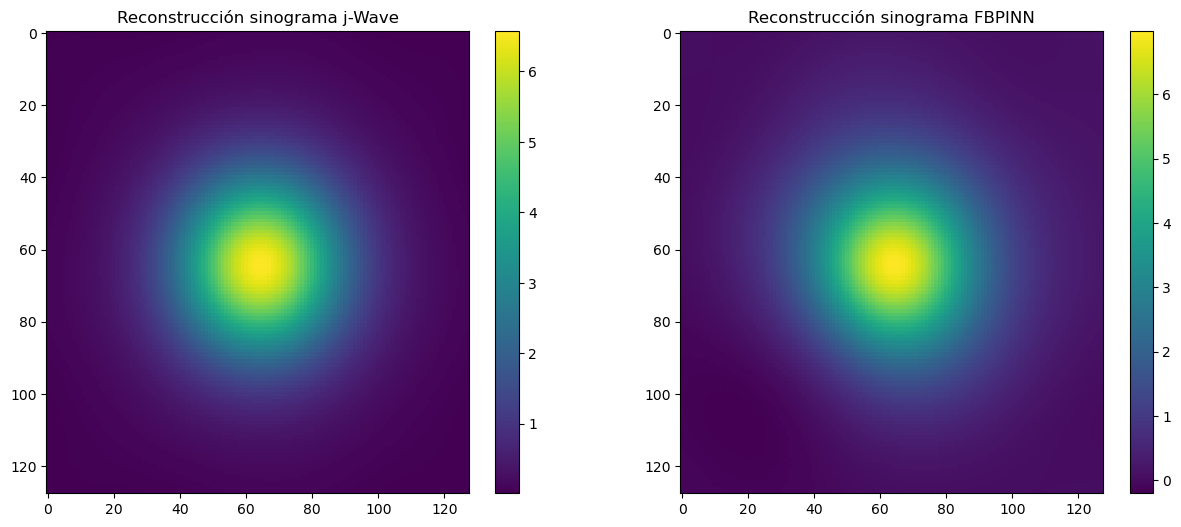

In [23]:
Pjwave = applyDAS(sinogram.shape[0],sinogram.shape[1],0.25,128,rx,360,1,0,50,sinogram).T
Pfbpinn = applyDAS(sinogram.shape[0],sinogram.shape[1],0.25,128,rx,360,1,0,50,sinogram_fbpinn).T
print("Para reconstrucciones: \n")
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
maxval = jnp.amax(jnp.abs(Pjwave))
plt.imshow(
    Pjwave,
    aspect="auto",
)
plt.title('Reconstrucción sinograma j-Wave')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(
    Pfbpinn,
    aspect="auto",
)
plt.title('Reconstrucción sinograma FBPINN')
plt.colorbar()

_ = metricas_imagen(Pjwave, Pfbpinn)

Para reconstrucciones con DAS:

MSE = 3.909e-02
RMSE = 1.977e-01
PSNR = 31.201287674802977
SSIM = 0.8305175720366628
PCC = 0.9939917969621455


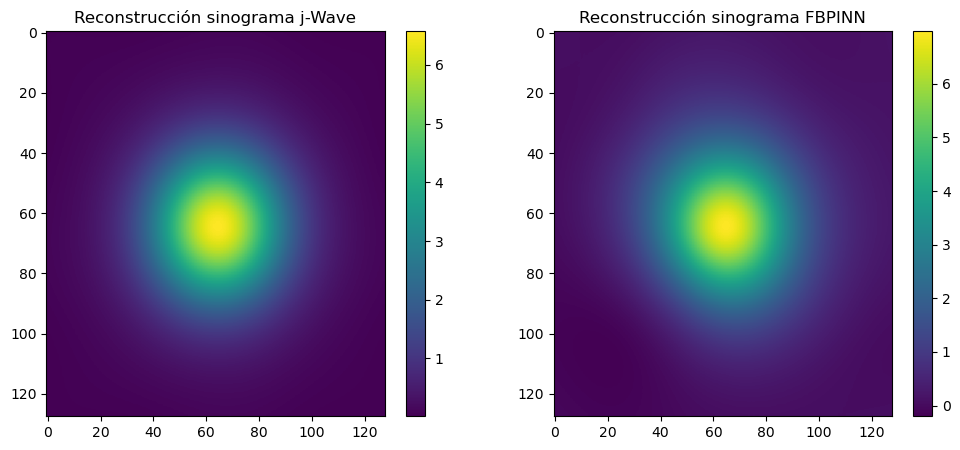

In [32]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.title('Reconstrucción sinograma j-Wave')
maxval = jnp.amax(jnp.abs(Pjwave))
plt.imshow(
    Pjwave,
    aspect="auto",
)
plt.colorbar()
plt.subplot(1,2,2)
plt.title('Reconstrucción sinograma FBPINN')
plt.imshow(
    Pfbpinn,
    aspect="auto",
)
plt.colorbar()
'''plt.subplot(1,3,3)
plt.title('Original')
plt.imshow(
    p0,
    aspect="auto",
)
plt.colorbar()'''

print("Para reconstrucciones con DAS:\n")
metricas_imagen(Pjwave, Pfbpinn)